# PROJET GNN 

Consignes : Téléchargez le graphe des aéroports augmenté avec les populations des villes. Vérifiez que vous êtes capables de charger dans un objet pytorch (voir le TP précédent pour les lignes à écrire pour que ça fonctionne).

Vérifier que vous êtes capable d'entraîner sur ce réseau l'un des GCN simples que vous avez écrits lors du premier TP.

In [77]:
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import torch as th
import torch.nn.functional as F
from matplotlib.cm import ScalarMappable
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from torch import nn
from torch_geometric.nn import VGAE, GCNConv
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.utils import from_networkx, to_networkx


## Getting started

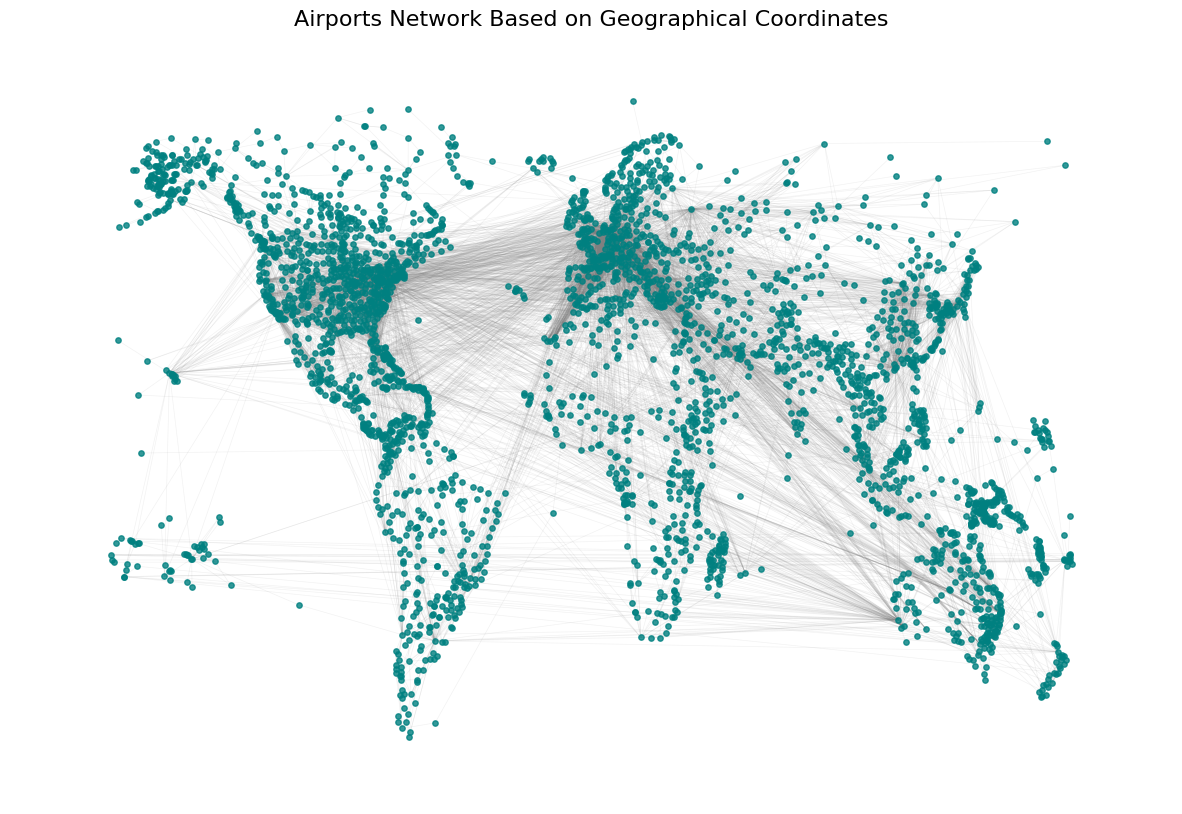

In [78]:
# loading data set 
# to prevent the hairball looking plot we use a virtual map

# loads the graphml file using networkx, turns nodes ids into ints 
G = nx.read_graphml("../graphes/airportsAndCoordAndPop.graphml", node_type=int)

# dic : longitude (lon) maps to the X-axis, latitude (lat) maps to the Y-axis
pos = {nœud: (float(donnees.get('lon', 0)), float(donnees.get('lat', 0))) 
       for nœud, donnees in G.nodes(data=True)}

plt.figure(figsize=(15, 10))
nx.draw_networkx_nodes(G, pos, node_size=15, node_color='teal', alpha=0.8)
# edges (very thin and transparent to avoid cluttering)
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.1, width=0.5)

plt.axis('off')
plt.title("Airports Network Based on Geographical Coordinates", fontsize=16)
plt.show()


In [79]:
# converting from networkx to pytorch geometric 
# transforms pop,lat,lon into matrix 
data = from_networkx(
    G, group_node_attrs=["population", "lat", "lon"]
)

# data : pytorch tensor
print("Data: ")
print(data)
print("\n")
# data.x : the matrix 
print("Data.x: ")
print(data.x)

# normalization

# echelle logarithmique pour la population
data.x[:, 0] = th.log1p(data.x[:, 0])

# nrmalisation Z-Score (moyenne 0, écart-type 1)
mean = data.x.mean(dim=0, keepdim=True)
std = data.x.std(dim=0, keepdim=True) + 1e-6

data.x = (data.x - mean) / std
print(data.x)

Data: 
Data(edge_index=[2, 27094], country=[3363], city_name=[3363], x=[3363, 3])


Data.x: 
tensor([[ 1.0000e+04, -1.7354e+01, -1.4551e+02],
        [ 1.0000e+04, -1.8067e+01, -1.4095e+02],
        [ 2.6357e+04, -1.7550e+01, -1.4960e+02],
        ...,
        [ 1.0000e+04,  5.4743e+01, -1.1320e+02],
        [ 1.0000e+04, -6.1333e+00,  1.4660e+02],
        [ 1.0000e+04, -6.0000e+00,  1.4725e+02]])
tensor([[-0.7928, -1.3764, -1.5155],
        [-0.7928, -1.4007, -1.4682],
        [-0.2578, -1.3831, -1.5579],
        ...,
        [-0.7928,  1.0814, -1.1806],
        [-0.7928, -0.9939,  1.5124],
        [-0.7928, -0.9894,  1.5191]])


In [80]:
# (d) Encode the class (country) using sklearn LabelEncoder 

encoder = LabelEncoder()
# encode countrys into numbers 
integer_labels = encoder.fit_transform(data.country)
# turns np tab into pytorch tensor 
target_tensor = th.tensor(integer_labels, dtype=th.long)
print("- target_tensor: ", target_tensor)

# target vector 
data.y = target_tensor
# total nb of classes (unique nb of countries)
data.num_classes = len(set(data.country))
print("\n- Number of classes :", data.num_classes)

# correspondence between the encoded number and the country name
print("\n- Class mapping :")
for index, country_name in enumerate(encoder.classes_):
  print(f"  Code {index} -> {country_name}")


- target_tensor:  tensor([ 66,  66,  66,  ...,  33, 143, 143])

- Number of classes : 212

- Class mapping :
  Code 0 -> AFGHANISTAN
  Code 1 -> ALBANIA
  Code 2 -> ALGERIA
  Code 3 -> AMERICAN_SAMOA
  Code 4 -> ANGOLA
  Code 5 -> ANGUILLA
  Code 6 -> ANTIGUA_AND_BARBUDA
  Code 7 -> ARGENTINA
  Code 8 -> ARMENIA
  Code 9 -> AUSTRALIA
  Code 10 -> AUSTRIA
  Code 11 -> AZERBAIJAN
  Code 12 -> BAHAMAS
  Code 13 -> BAHRAIN
  Code 14 -> BANGLADESH
  Code 15 -> BARBADOS
  Code 16 -> BELARUS
  Code 17 -> BELGIUM
  Code 18 -> BELIZE
  Code 19 -> BENIN
  Code 20 -> BERMUDA
  Code 21 -> BHUTAN
  Code 22 -> BOLIVIA
  Code 23 -> BOSNIA-HERZEGOVINA
  Code 24 -> BOTSWANA
  Code 25 -> BRAZIL
  Code 26 -> BRITISH_VIRGIN_ISLANDS
  Code 27 -> BRUNEI
  Code 28 -> BULGARIA
  Code 29 -> BURKINA_FASO
  Code 30 -> BURUNDI
  Code 31 -> CAMBODIA
  Code 32 -> CAMEROON
  Code 33 -> CANADA
  Code 34 -> CAPE_VERDE
  Code 35 -> CAYMAN_ISLANDS
  Code 36 -> CHAD
  Code 37 -> CHILE
  Code 38 -> CHINA
  Code 39 -> COLO

In [81]:
# (e) Let’s consider that for some of the city, we don’t know their country, but we want to
# train a model to guess the country they belong to.

# total nb of airports 
num_nodes = data.num_nodes
# random shuffle to make the model learn more equitably
perm = th.randperm(num_nodes)

# 70% for training, 15% for validation, 15% (rest) for test
train_size = int(0.70 * num_nodes)
val_size = int(0.15 * num_nodes)

# init of the vectors with false (will be used later during learning)
data.train_mask = th.zeros(num_nodes, dtype=th.bool)
data.val_mask = th.zeros(num_nodes, dtype=th.bool)
data.test_mask = th.zeros(num_nodes, dtype=th.bool)

# activate some index for each vector 
data.train_mask[perm[:train_size]] = True
data.val_mask[perm[train_size : train_size + val_size]] = True
data.test_mask[perm[train_size + val_size :]] = True

## Predict using a GCN

In [82]:
# building GCN, with a single layer. It should solve a classification problem, with 212 classes.
import copy 
# class for le reseau de neurone 
class Model(nn.Module):
    """Graph Convolutional network"""
    # init constructor
    # dim_in takes 3 entries for each node: pop, lat, lon
    # dim_out exit prediction 
    def __init__(self, dim_in, dim_out, hidden_dim=64):
        super().__init__()
        self.gcn1 = GCNConv (dim_in, hidden_dim) #add_self_loops=False
        self.gcn2 = GCNConv(hidden_dim, dim_out)
    # graph convolution + log-softmax 
    def forward(self, x, edge_index):
        h = self.gcn1(x,edge_index)
        h = F.relu(h)
        h = self.gcn2(h, edge_index)
        return F.log_softmax(h, dim=1)

# training 
def train(data, model, epochs, patience=100):
    criterion = th.nn.NLLLoss() #CrossEntropyLoss() # mesure diff predic/truth
    optimizer = th.optim.Adam(
        model.parameters(), lr=0.01, weight_decay=5e-4
        )

    # variables for Early Stopping to prevent the overfitting
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_weights = None

    #model.train()

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        # validation phase for Early Stopping
        model.eval()
        with th.no_grad():
            val_out = model(data.x, data.edge_index)
            val_loss = criterion(val_out[data.val_mask], data.y[data.val_mask])

        # early Stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            # Save the best model weights
            best_model_weights = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1

        if epoch % 30 == 0 or epoch == 1:
            print(f'Epoch {epoch:03d} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}')

        # stop training if validation loss hasn't improved
        if patience_counter >= patience:
            print(f'\n[Early Stopping] Stopped at epoch {epoch}. No improvement for {patience} epochs.')
            break

    # restore the best model weights after training stops
    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)


In [83]:
def test(data, model):
    model.eval()
    with th.no_grad():
        out = model(data.x, data.edge_index)
        pred = out.argmax(dim=1)

    test_acc = (
        pred[data.test_mask] == data.y[data.test_mask]
    ).sum().item() / data.test_mask.sum().item()
    print(f"test_acc: {test_acc:4f}")
    return pred

In [84]:
# here instanciate the model, then train and test it
model = Model(dim_in=data.x.shape[1], dim_out=212)
train(data, model, epochs=300)


Epoch 001 | Train Loss: 5.3310 | Val Loss: 5.2146
Epoch 030 | Train Loss: 2.6470 | Val Loss: 2.7063
Epoch 060 | Train Loss: 2.0204 | Val Loss: 2.2052
Epoch 090 | Train Loss: 1.7696 | Val Loss: 2.0112
Epoch 120 | Train Loss: 1.6095 | Val Loss: 1.8954
Epoch 150 | Train Loss: 1.4982 | Val Loss: 1.8214
Epoch 180 | Train Loss: 1.4205 | Val Loss: 1.7757
Epoch 210 | Train Loss: 1.3637 | Val Loss: 1.7445
Epoch 240 | Train Loss: 1.3195 | Val Loss: 1.7227
Epoch 270 | Train Loss: 1.2838 | Val Loss: 1.7044
Epoch 300 | Train Loss: 1.2537 | Val Loss: 1.6906


In [85]:
# (d) Print the targets and the predictions for all the nodes

model.eval()
with th.no_grad():
  pred = model(data.x, data.edge_index).argmax(dim=1)

print("- Targets (vraies classes) :")
print(data.y)

print("\n- Predictions :")
print(pred)

# calcul et affichage du pourcentage
total = data.num_nodes
bonnes = (pred == data.y).sum().item()
mauvaises = total - bonnes

taux_reussite = (bonnes / total) * 100
taux_erreur = (mauvaises / total) * 100

print(
    f"\n => Résultat : {bonnes}/{total} bonnes réponses"
)

# strict test 
correct_test = (
    pred[data.test_mask] == data.y[data.test_mask]
).sum().item()
total_test = data.test_mask.sum().item()
acc_test = (correct_test / total_test) * 100

print(
    f" => Résultat Test (Examen) : {correct_test}/{total_test} bonnes réponses ({acc_test:.2f}%)"
)


- Targets (vraies classes) :
tensor([ 66,  66,  66,  ...,  33, 143, 143])

- Predictions :
tensor([ 66,  66,  43,  ...,  33, 143, 143])

 => Résultat : 2227/3363 bonnes réponses
 => Résultat Test (Examen) : 324/505 bonnes réponses (64.16%)


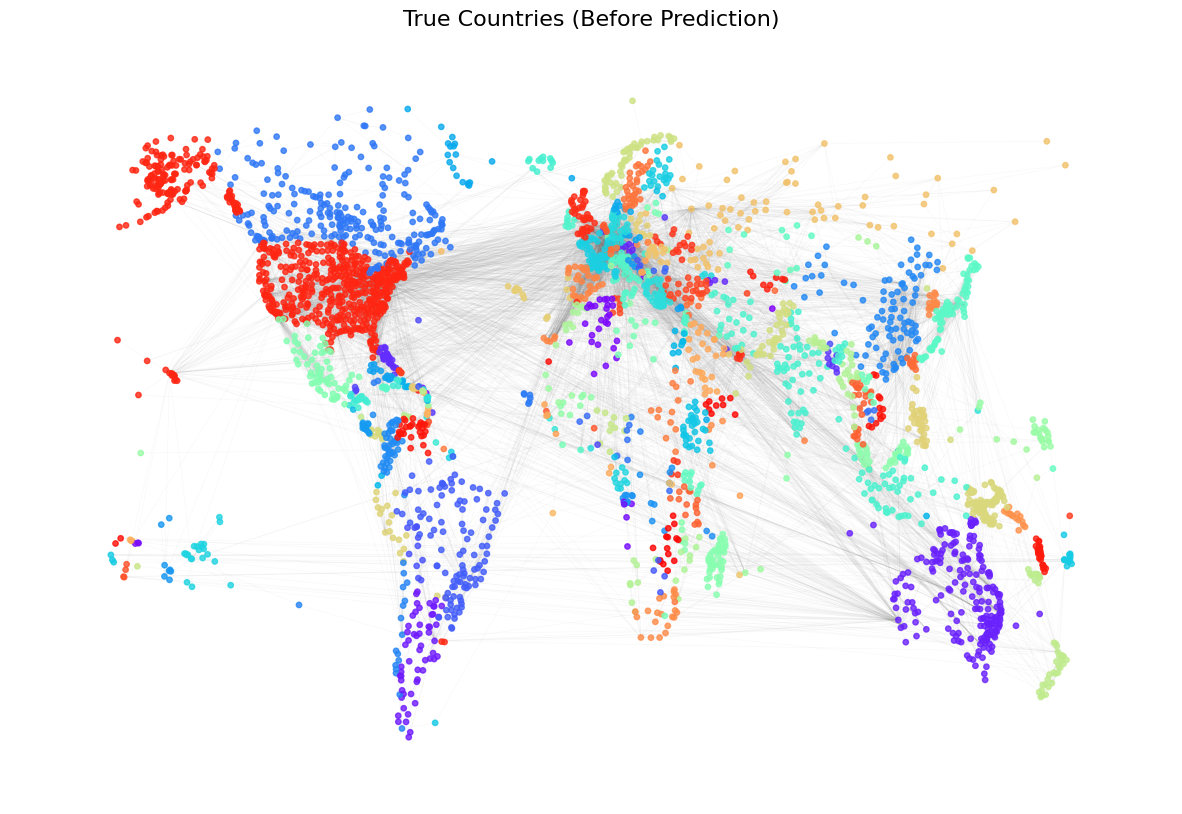

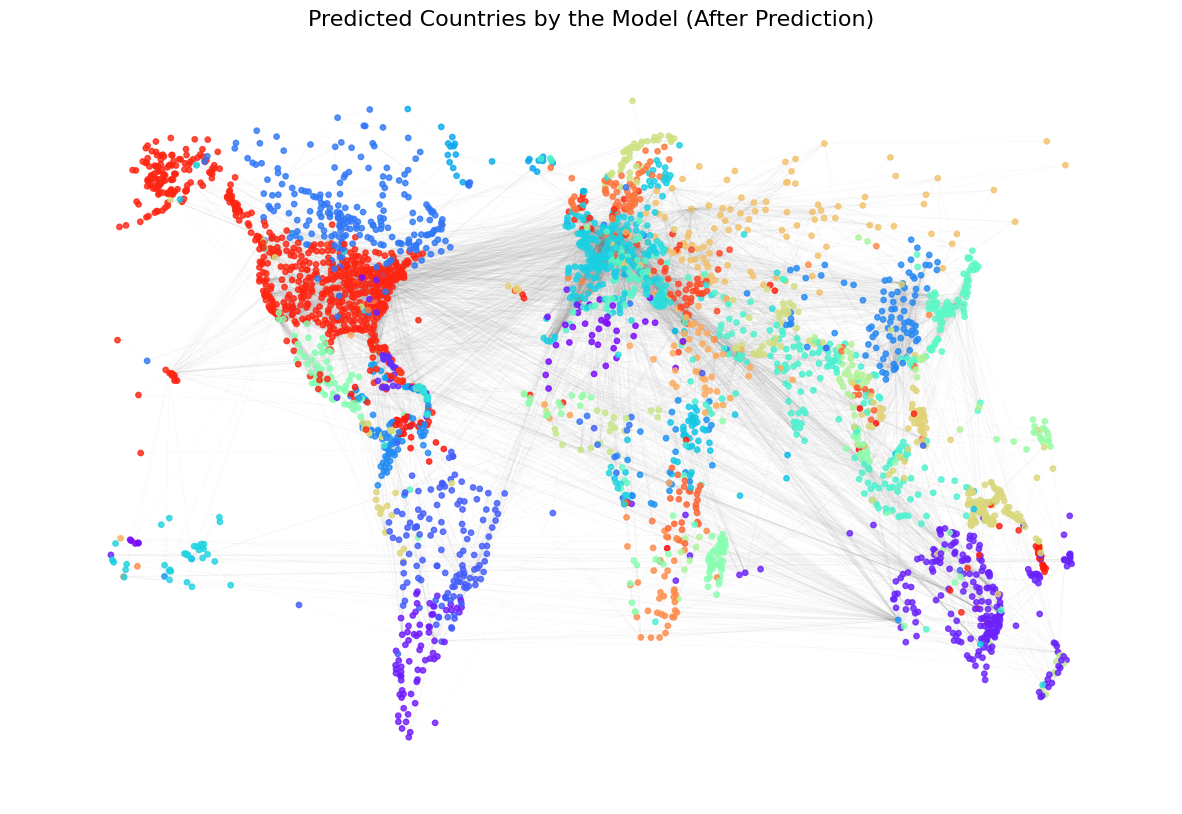

In [86]:
# (g) Print the network using networkx, with node colors corresponding first to student’s preference, then
# to nodes clubs, before and after prediction, to observe intuitively that the results are convincing.
# Here is an example to guide you
import numpy as np
import matplotlib as mpl

# récupération des prédictions du modèle
model.eval()
with th.no_grad():
    pred = model(data.x, data.edge_index).argmax(dim=1)

# fixed palette 
all_classes = np.unique(data.y.cpu().numpy())
colormap = mpl.colormaps["rainbow"].resampled(len(all_classes))
global_class_to_color = {c: colormap(i) for i, c in enumerate(all_classes)}


def afficher_graphe(attribute_tensor, title):
    # Assign a color to each node based on the attribute tensor
    node_colors = [global_class_to_color.get(val.item(), (0, 0, 0, 1))
        for val in attribute_tensor]

    # Plotting configuration
    plt.figure(figsize=(15, 10))
    
    nx.draw_networkx_nodes(G, pos=pos, node_size=15, node_color=node_colors, alpha=0.8)
    nx.draw_networkx_edges(G, pos=pos, edge_color='gray', alpha=0.05, width=0.5)
    
    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.show()

afficher_graphe(data.y, "True Countries (Before Prediction)")

afficher_graphe(pred, "Predicted Countries by the Model (After Prediction)")

## Predicting edges using a VGAE

In [87]:
# (a) This time, we want to predict edges. Start back from the original network, without hidden information.


In [88]:
# Build a train test split using the RandomLinkSplit class
# You don’t need a validation set, the graph is undirected 
# and we have to split labels to easily differentiate positive edges from negative edges
# https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.transforms.RandomLinkSplit.html#torch_geometric.transforms.RandomLinkSplit
transform = RandomLinkSplit(
    num_val=0.1,          # 10% des arêtes cachées pour la validation
    num_test=0.2,         # 20% des arêtes cachées pour le test final
    is_undirected=True,   
    split_labels=True,
    add_negative_train_samples=False 
)

# train_data contient le graphe avec certaines arêtes masquées (pour apprendre)
# val_data et test_data contiennent les arêtes masquées (pour vérifier)
train_data, val_data, test_data = transform(data)

print("Arêtes pour l'entraînement :", train_data.pos_edge_label_index.shape[1])
print("Arêtes cachées pour le test :", test_data.pos_edge_label_index.shape[1])

Arêtes pour l'entraînement : 9484
Arêtes cachées pour le test : 2709


In [89]:
# (b) Build your Encoder which compute mu and logstd of a distribution
# and the train function associated
class Encoder(nn.Module):
    def __init__(self, dim_in, dim_out) :
          super().__init__()
          self.conv1 = GCNConv(dim_in, 2 * dim_out)
          self.conv_mu = GCNConv(2 * dim_out, dim_out) # moyenne
          self.conv_logstd = GCNConv(2 * dim_out, dim_out) # ecart-type

    def forward(self, x, edge_index) :
     x = self.conv1(x, edge_index).relu()
     return self.conv_mu(x, edge_index), self.conv_logstd(x, edge_index)
     
    
def train(model, data, epochs):
    model.train()
    optimizer.zero_grad()
    z = model.encode(train_data.x, train_data.edge_index)
    loss = model.recon_loss(z, train_data.pos_edge_label_index) + (1/ train_data.num_nodes) * model.kl_loss()
    loss.backward()
    optimizer.step()
    return float(loss)

In [90]:
dim_in = data.num_features 
dim_out = 16  # size of the reduced latent space (embeddings)

# Initialization 
encoder = Encoder(dim_in, dim_out)
model = VGAE(encoder)
optimizer = th.optim.Adam(model.parameters(), lr=0.01)

# training loop
epochs = 100
for epoch in range(1, epochs + 1):
    loss = train(model, train_data, epoch) 
    
    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:03d} | Loss: {loss:.4f}')

Epoch 001 | Loss: 3.8202
Epoch 010 | Loss: 1.5085
Epoch 020 | Loss: 1.0925
Epoch 030 | Loss: 0.9895
Epoch 040 | Loss: 0.9641
Epoch 050 | Loss: 0.9384
Epoch 060 | Loss: 0.9364
Epoch 070 | Loss: 0.9283
Epoch 080 | Loss: 0.9155
Epoch 090 | Loss: 0.9193
Epoch 100 | Loss: 0.9079


In [91]:
# (d) Evaluate your model. Be careful to use training data for training and testing data for testing :)
# Something like:
z = model.encode(train_data.x, data.edge_index)
model.test(z, test_data.pos_edge_label_index, test_data.neg_edge_label_index)  # it give AUC and AP

(0.9617559340704415, 0.9617503578852301)

In [92]:
# (e) Check that you are able to reconstruct the original graph, by applying the dot product between
# node vectors. You can do it with something like:
pred_scores = th.sigmoid((z[test_data.pos_edge_label_index[0]] * z[test_data.pos_edge_label_index[1]]).sum(dim=1)).detach().numpy()

# how many edge are predicted with a score upon 0.5 ?
nombre_aretes_predites = (pred_scores > 0.5).sum()

print(f"Nombre d'arêtes prédites avec un score > 0.5 : {nombre_aretes_predites}")
print(f"Sur un total de : {len(pred_scores)} arêtes testées")

Nombre d'arêtes prédites avec un score > 0.5 : 2689
Sur un total de : 2709 arêtes testées


NetworkXError: Node 2408 has no position.

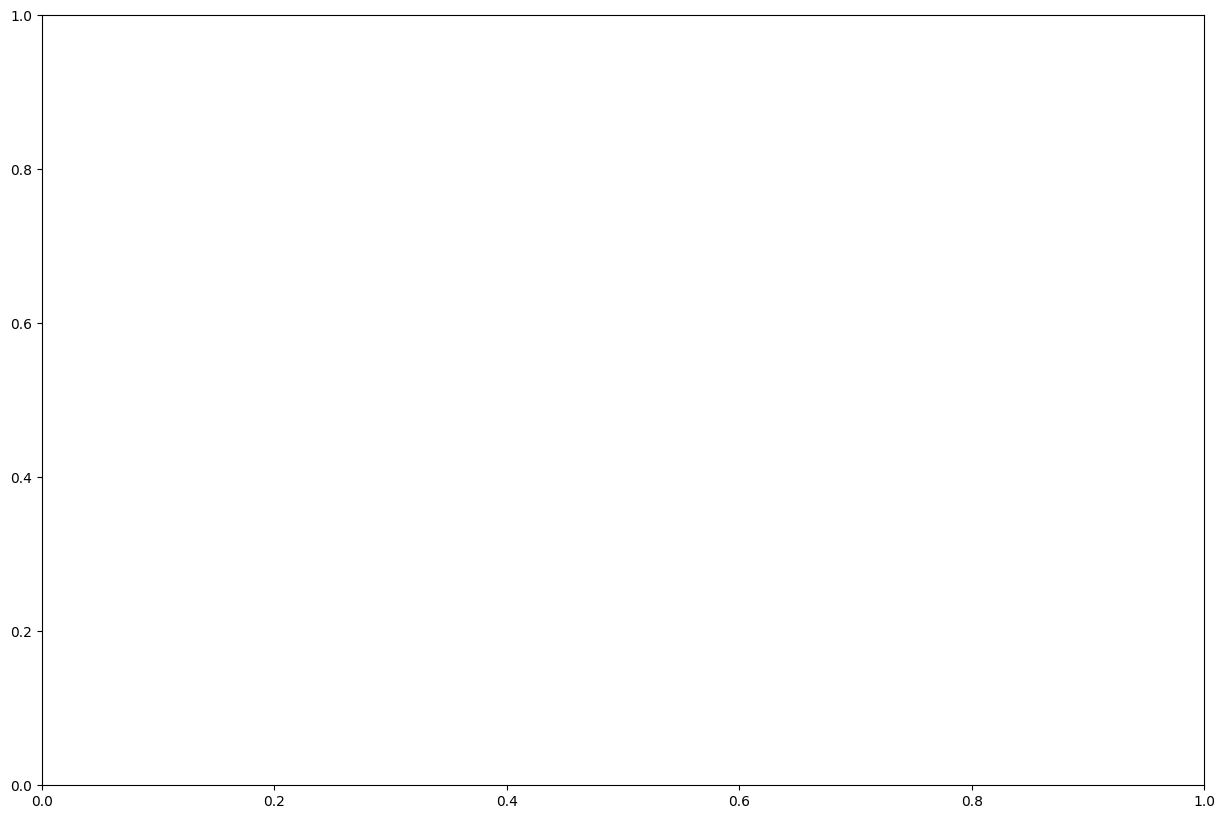

In [93]:
import matplotlib.pyplot as plt
import networkx as nx

# (f) Using networkx, plot the original network, plus some of the edges considered as the most likely.
# You can use a color scale to represent the likeliness of observing an edge

# Set edge_index to the positive edges we want to evaluate/reconstruct
test_data.edge_index = test_data.pos_edge_label_index
new_G = to_networkx(test_data, to_undirected=True)

edges_to_draw = []
edge_colors = []

# Iterate over predicted scores to filter likely edges
for i in range(len(pred_scores)):
    # Edges considered probable (score > 0.5)
    if pred_scores[i] > 0.5:
        u = int(test_data.pos_edge_label_index[0, i])
        v = int(test_data.pos_edge_label_index[1, i])
        edges_to_draw.append((u, v))
        # We can use item() if pred_scores is a tensor to extract the float value
        edge_colors.append(pred_scores[i].item() if hasattr(pred_scores[i], 'item') else pred_scores[i])

# 1. Enlarge the figure for better visibility
plt.figure(figsize=(15, 10))

# 2. Draw nodes (smaller size, no labels to avoid the hairball effect)
# Assuming 'pos' is still defined using lat/lon from earlier steps
nx.draw_networkx_nodes(new_G, pos=pos, node_size=15, node_color='lightgray', alpha=0.5)

# NOTE: nx.draw_networkx_labels is INTENTIONALLY REMOVED here to keep the map clean

# 3. Draw reconstructed edges with a colormap
edges = nx.draw_networkx_edges(
    new_G, 
    pos=pos, 
    edgelist=edges_to_draw, 
    edge_color=edge_colors, 
    edge_cmap=plt.cm.viridis,  # From purple (0.5) to yellow (1.0)
    edge_vmin=0.5,             
    edge_vmax=1.0,             
    width=0.8,                 # Reduced width
    alpha=0.7                  # Added transparency to see overlapping connections
)

# Add colorbar, title, and hide axes
plt.colorbar(edges, label="Probability (Score)")
plt.title("Reconstructed Edges Based on Prediction Probability", fontsize=16)
plt.axis('off')

plt.show()

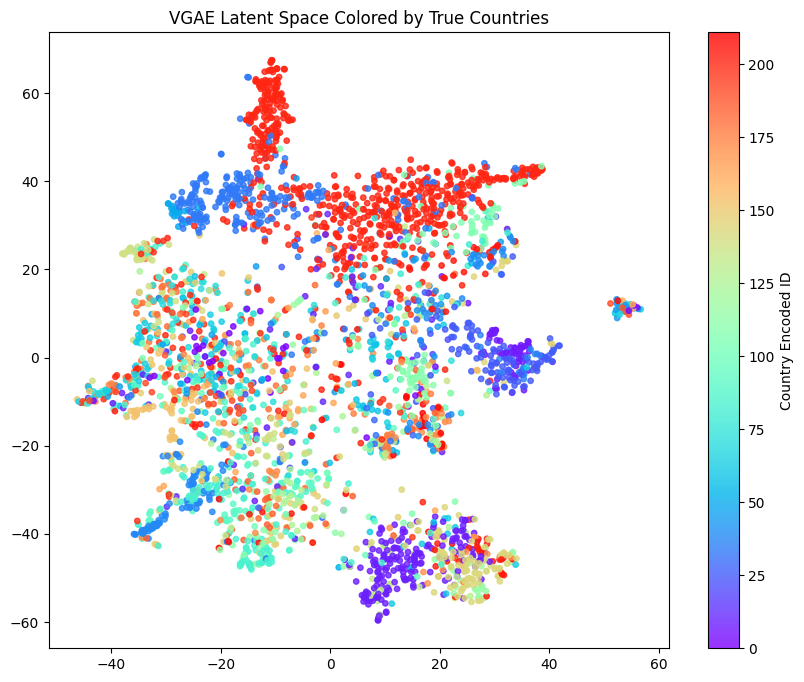

In [ ]:
# (g) with TSNE we can visualize the sampled latent space of our VGAE.
# add color of classes to understand if its a meaningful representation or not
z_2d = TSNE(n_components=2, random_state=42).fit_transform(z.cpu().detach().numpy())

plt.figure(figsize=(10, 8))

# We pass the numerical labels directly to 'c' and use the 'rainbow' colormap
# This avoids the KeyError and automatically colors the 212 countries
scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=data.y.cpu().numpy(), cmap='rainbow', s=15, alpha=0.8)

plt.title("VGAE Latent Space Colored by True Countries")

# Optional: Add a colorbar to show the scale of country IDs
plt.colorbar(scatter, label="Country Encoded ID")

plt.show()